# Fire incidence in 2025: from mainland Portugal to the study area

**Purpose.** An exploratory look at the official ICNF burned-area records for 2025
(`ardida_2025`), structured top down: first the national picture for context, then
a drill-down into the study area, Sentinel-2 tile T29TPG in Trás-os-Montes, which
is what this project actually maps. It describes when fires happened, how big they
were, what caused them, what burned, and where.

**Dataset.** ICNF burned-area cartography for mainland Portugal, 2025: one polygon
per fire event with start and end dates, total burned area with a forest /
shrubland / agriculture split, cause type, and administrative location.

## 1. Setup and data

This section loads the records, derives the fields we explore, and splits the data
into the national set and the study-area subset (the fires inside tile T29TPG).

### 1.1 Environment and plotting style

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 140, "font.size": 11,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
ACCENT = "#d6604d"           # fire red
NAT    = "0.75"              # grey (national context)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for _c in (Path.cwd(), Path.cwd().parent):
    if (_c / "data" / "shapefiles").exists():
        REPO = _c; break

### 1.2 Load the records and define the study area

Read the shapefile, parse dates, and derive month, total burned area (`AreaHaSIG`),
cause and land cover. The study area is the footprint of Sentinel-2 tile T29TPG,
defined by the standard tile bounds (EPSG:32629), not by any rasterised product.
The ICNF data is Portugal-only, so clipping to the tile gives the Portuguese fires
inside it.

In [2]:
ICNF = REPO / "data/shapefiles/ground_truth_ICNF/ardida_2025.shp"
f = gpd.read_file(ICNF)
f["start"] = pd.to_datetime(f["DH_Inicio"], errors="coerce")
f["end"]   = pd.to_datetime(f["DH_Fim"], errors="coerce")
f["month"] = f["start"].dt.month
f["ha"]    = f["AreaHaSIG"].astype(float)
f["cause"] = f["Causa_Tipo"].fillna("Unknown")
f = f[f["ha"] > 0].copy()

# Sentinel-2 tile T29TPG footprint (left, right, bottom, top) in EPSG:32629.
# These are the standard MGRS tile bounds, not derived from the ICNF data.
TILE = (600000.0, 709800.0, 4590240.0, 4653280.0)
f32 = f.to_crs("EPSG:32629")
in_tile = f32.cx[TILE[0]:TILE[1], TILE[2]:TILE[3]].index
fa = f.loc[in_tile].copy()                                                   # study-area fires

print(f"national : {len(f):,} fires, {f['ha'].sum():,.0f} ha burned in 2025")
print(f"study area (T29TPG): {len(fa):,} fires, {fa['ha'].sum():,.0f} ha "
      f"({100*len(fa)/len(f):.0f}% of fires, {100*fa['ha'].sum()/f['ha'].sum():.1f}% of area)")

national : 2,084 fires, 272,453 ha burned in 2025
study area (T29TPG): 182 fires, 13,035 ha (9% of fires, 4.8% of area)


## 2. National context

A brief look at mainland Portugal in 2025, to place the study area in the wider
picture before zooming in.

#### 2.1.1 The 2025 fire season

**Objective.** Headline national numbers and the burned area by month, to show how
concentrated the season was. **Assumption.** Month from the start date.

In [3]:
nat_month = f.groupby("month")["ha"].sum().reindex(range(1, 13), fill_value=0)
print(f"national: {len(f):,} fires, {f['ha'].sum():,.0f} ha, largest {f['ha'].max():,.0f} ha")
print(f"August share of burned area: {100*nat_month.iloc[7]/f['ha'].sum():.0f}%")

national: 2,084 fires, 272,453 ha, largest 65,853 ha
August share of burned area: 80%


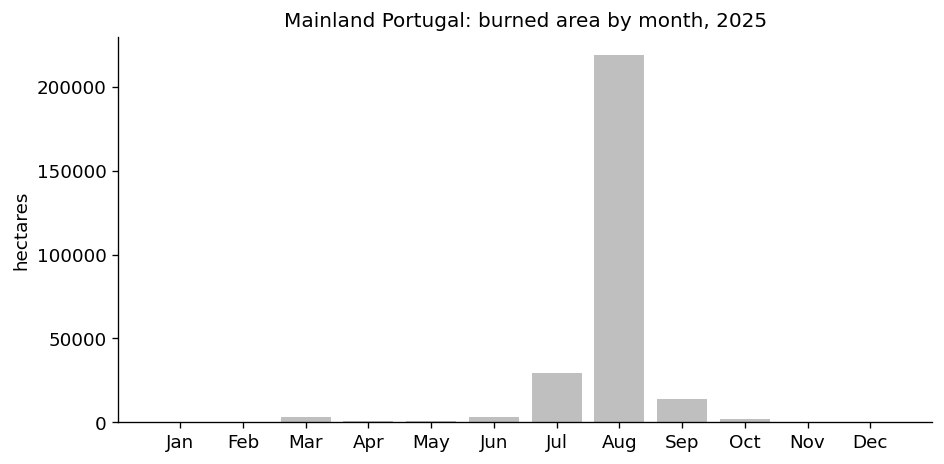

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(MONTHS, nat_month.values, color=NAT)
ax.set_ylabel("hectares"); ax.set_title("Mainland Portugal: burned area by month, 2025")
plt.tight_layout(); plt.show()

*Observation.* 2025 was an extreme year, and the burned area was overwhelmingly
concentrated in August. The fire season in Portugal is short and sharp, which is
why the before/after scene pair has to bracket it. The study area shares this
pattern, as the rest of the notebook shows.

## 3. The study area: Sentinel-2 tile T29TPG

The detailed exploration, restricted to the fires inside the study area.

### 3.1 Study-area overview

#### 3.1.1 Headline numbers

**Objective.** Summarize the study-area fires. **Assumption.** Size is `AreaHaSIG`.

In [5]:
summary = pd.Series({
    "fire events": len(fa),
    "total burned (ha)": fa["ha"].sum(),
    "mean size (ha)": fa["ha"].mean(),
    "median size (ha)": fa["ha"].median(),
    "largest fire (ha)": fa["ha"].max(),
    "fires >= 65 ha": int((fa["ha"] >= 65).sum()),
    "fires < 1 ha": int((fa["ha"] < 1).sum()),
})
summary.round(1)

fire events            182.0
total burned (ha)    13035.4
mean size (ha)          71.6
median size (ha)         2.0
largest fire (ha)     4196.6
fires >= 65 ha          15.0
fires < 1 ha            46.0
dtype: float64

*Observation.* As nationally, the study area is dominated in count by small
fires but in area by a few large ones, the same heavy-tailed signature.

#### 3.1.2 Map of the study-area fires

**Objective.** Map the 2025 fire perimeters inside tile T29TPG, with the
Portugal-Spain border that crosses the tile for reference. **Assumption.** Plotted
in EPSG:32629, zoomed to the tile footprint.

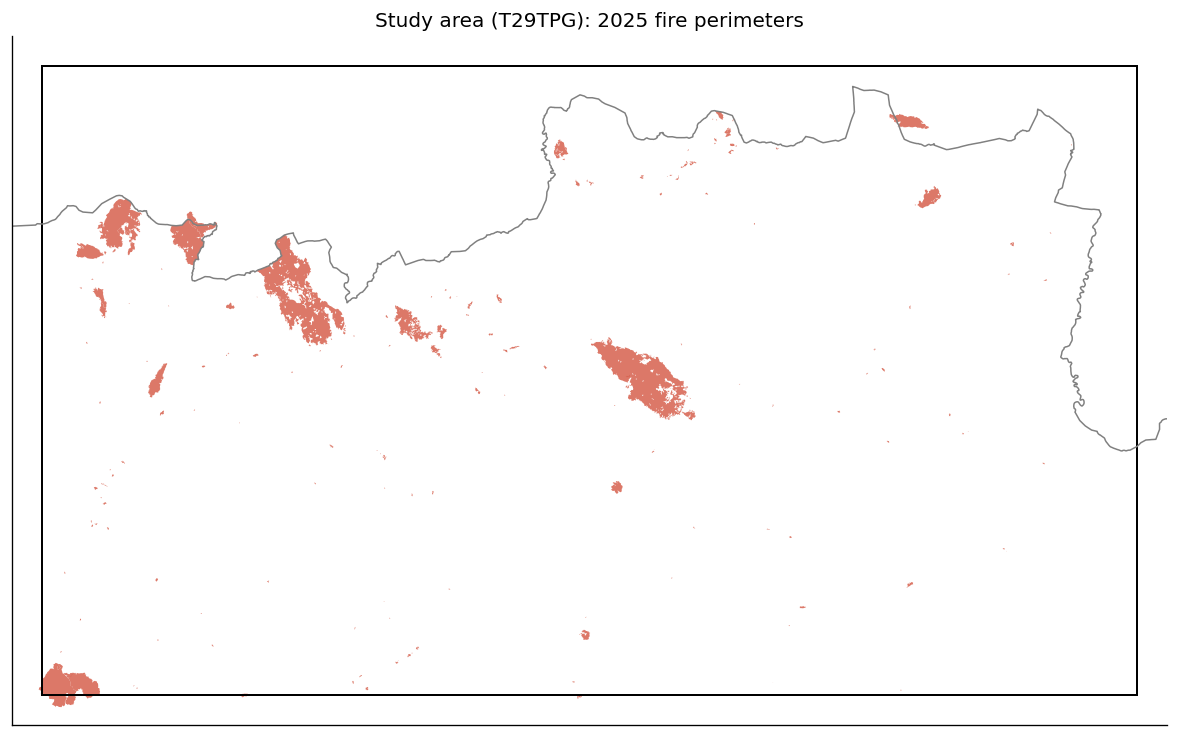

In [6]:
PT = gpd.read_file(REPO / "data/shapefiles/boundary_files/portugal_continental_32629.gpkg").to_crs("EPSG:32629")
fa32 = fa.to_crs("EPSG:32629")
fig, ax = plt.subplots(figsize=(10, 6.2))
PT.boundary.plot(ax=ax, color="0.5", linewidth=0.9)
fa32.plot(ax=ax, color=ACCENT, edgecolor="none", alpha=0.85)
ax.add_patch(plt.Rectangle((TILE[0], TILE[2]), TILE[1]-TILE[0], TILE[3]-TILE[2],
                           fill=False, edgecolor="black", linewidth=1.2))
ax.set_xlim(TILE[0]-3000, TILE[1]+3000); ax.set_ylim(TILE[2]-3000, TILE[3]+3000)
ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
ax.set_title("Study area (T29TPG): 2025 fire perimeters")
plt.tight_layout(); plt.show()

*Observation.* The burned areas concentrate in the western and central parts
of the tile (Montalegre, Vinhais, Ribeira de Pena); the grey line is the
Portugal-Spain border, and only the Portuguese side carries ICNF perimeters.

### 3.2 Temporal pattern

#### 3.2.1 Fires and burned area by month

**Objective.** Count fires and sum burned area per month, in the study area.
**Assumption.** Month from the start date.

In [7]:
by_month = fa.groupby("month").agg(fires=("ha", "size"), ha=("ha", "sum")).reindex(range(1, 13), fill_value=0)
by_month.index = MONTHS
by_month.round(0)

,fires,ha
Jan,2,3.0
Feb,0,0.0
Mar,21,421.0
Apr,15,203.0
May,1,10.0
Jun,7,13.0
Jul,26,542.0
Aug,40,9166.0
Sep,40,2071.0
Oct,30,606.0


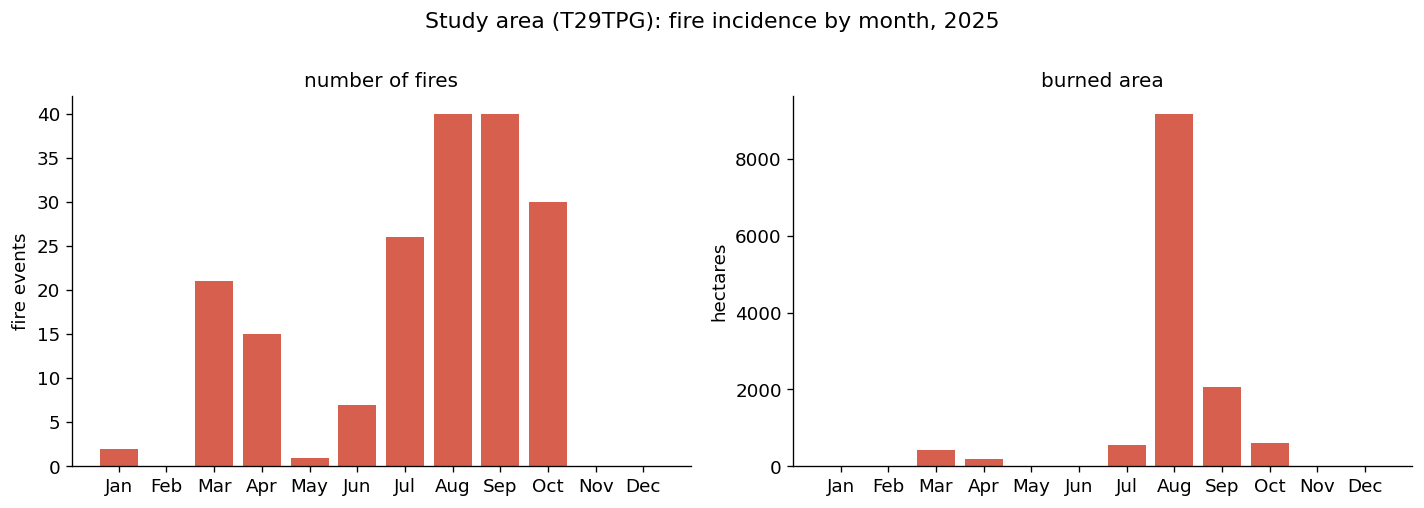

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(MONTHS, by_month["fires"], color=ACCENT); axes[0].set_title("number of fires"); axes[0].set_ylabel("fire events")
axes[1].bar(MONTHS, by_month["ha"], color=ACCENT); axes[1].set_title("burned area"); axes[1].set_ylabel("hectares")
fig.suptitle("Study area (T29TPG): fire incidence by month, 2025", y=1.0)
plt.tight_layout(); plt.show()

*Observation.* In the study area the burned area is concentrated in August and
September, the window the before/after pair must bracket. The count and area peaks
need not coincide.

### 3.3 Fire size distribution

#### 3.3.1 Size statistics and histogram

**Objective.** Describe the spread of study-area fire sizes. **Assumption.** Heavy
tailed, so the size axis is logarithmic.

In [9]:
pct = fa["ha"].quantile([0.5, 0.9, 0.95, 0.99]).round(2)
print("size percentiles (ha):"); print(pct.to_string())
print(f"\nsmallest {fa['ha'].min():.2f} ha | largest {fa['ha'].max():,.0f} ha")

size percentiles (ha):
0.50       1.98
0.90      35.12
0.95     247.35
0.99    1492.89

smallest 0.05 ha | largest 4,197 ha


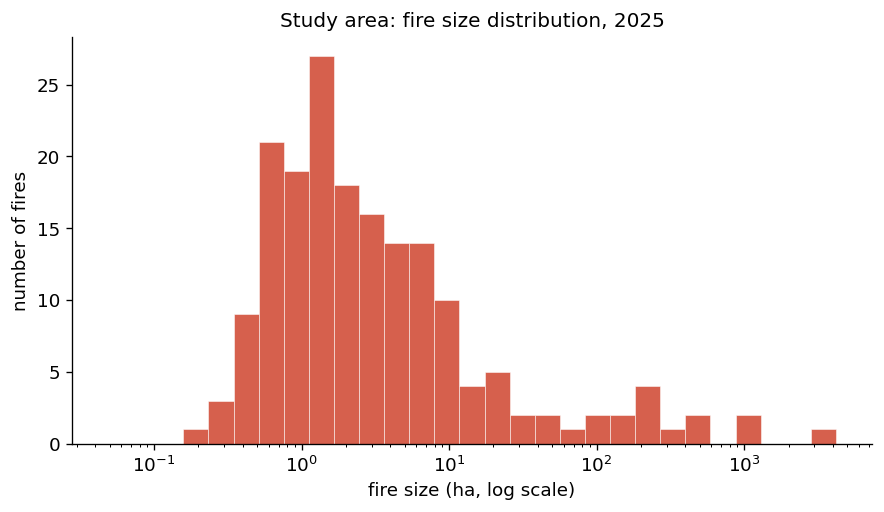

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
bins = np.logspace(np.log10(max(fa["ha"].min(), 0.01)), np.log10(fa["ha"].max()), 30)
ax.hist(fa["ha"], bins=bins, color=ACCENT, edgecolor="white", linewidth=0.3)
ax.set_xscale("log"); ax.set_xlabel("fire size (ha, log scale)"); ax.set_ylabel("number of fires")
ax.set_title("Study area: fire size distribution, 2025")
plt.tight_layout(); plt.show()

*Observation.* Most study-area fires are small, with a long tail to the few
thousand-hectare events. This heavy tail is why burned pixels are a small, clustered
fraction of the tile.

#### 3.3.2 Size classes

**Objective.** Show how fire count and burned area split between size classes.
**Assumption.** The official ICNF rural-fire size classes (ha): ]0-1[, [1-10[, [10-20[, [20-50[, [50-100[, [100-500[, [500-1000[, [1000+[.

In [11]:
# Official ICNF rural-fire size classes (ha), left-inclusive intervals
edges = [0, 1, 10, 20, 50, 100, 500, 1000, np.inf]
labs = ["]0-1[", "[1-10[", "[10-20[", "[20-50[", "[50-100[", "[100-500[", "[500-1000[", "[1000+["]
fa["size_class"] = pd.cut(fa["ha"], bins=edges, labels=labs, right=False)
cls = fa.groupby("size_class", observed=True).agg(fires=("ha", "size"), ha=("ha", "sum"))
cls["fires_%"] = 100*cls["fires"]/cls["fires"].sum(); cls["ha_%"] = 100*cls["ha"]/cls["ha"].sum()
cls.round(1)

,fires,ha,fires_%,ha_%
size_class,,,,
]0-1[,46,28.2,25.3,0.2
[1-10[,103,332.7,56.6,2.6
[10-20[,10,134.7,5.5,1.0
[20-50[,5,133.6,2.7,1.0
[50-100[,4,262.2,2.2,2.0
[100-500[,9,2186.0,4.9,16.8
[500-1000[,2,1499.7,1.1,11.5
[1000+[,3,8458.3,1.6,64.9


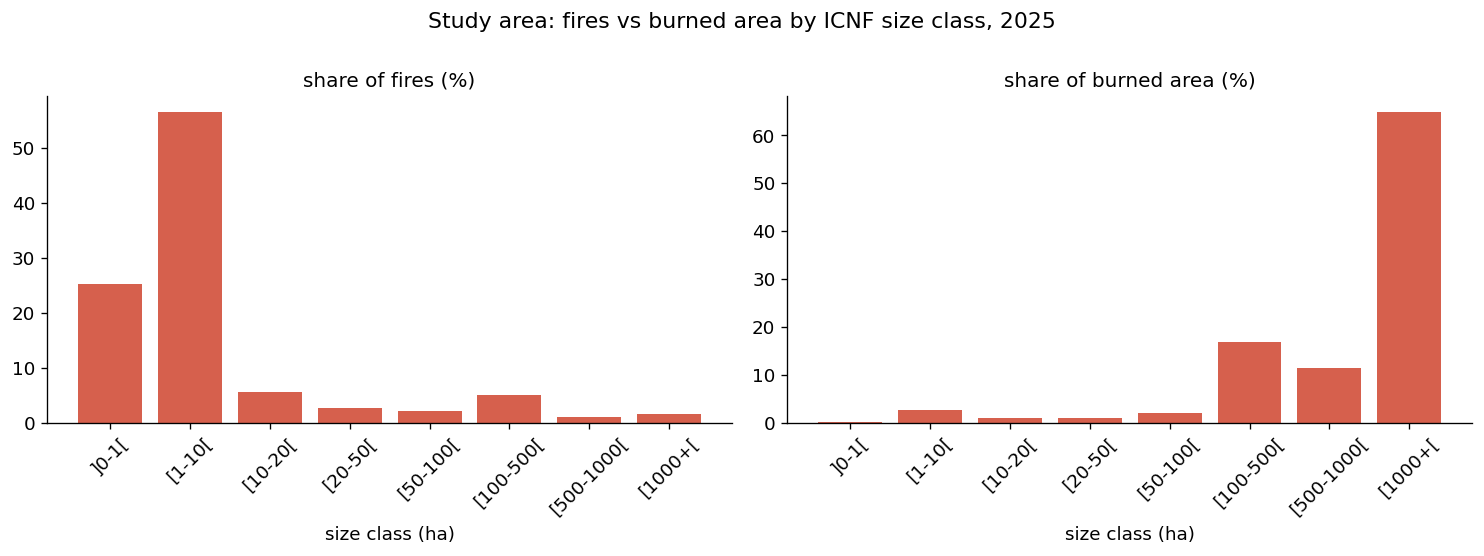

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].bar(labs, cls["fires_%"], color=ACCENT); axes[0].set_title("share of fires (%)")
axes[1].bar(labs, cls["ha_%"], color=ACCENT); axes[1].set_title("share of burned area (%)")
for ax in axes:
    ax.set_xlabel("size class (ha)"); ax.tick_params(axis="x", rotation=45)
fig.suptitle("Study area: fires vs burned area by ICNF size class, 2025", y=1.0)
plt.tight_layout(); plt.show()

*Observation.* The smallest classes hold most fires but little area; a few
large fires hold most of the burned area. This is the practical case for a minimum
fire-size filter: dropping the smallest detections costs little real burned area.

#### 3.3.3 Largest fire events

**Objective.** List the biggest study-area fires with their dates, the events the
before/after pair most needs to bracket. **Assumption.** Ranked by size.

In [13]:
big = fa.sort_values("ha", ascending=False).head(10)
big[["start", "end", "ha", "PI_Distrit", "PI_Conc", "cause"]].assign(
    start=big["start"].dt.date, end=big["end"].dt.date, ha=big["ha"].round(0)).reset_index(drop=True)

,start,end,ha,PI_Distrit,PI_Conc,cause
0,2025-08-18,2025-08-21,4197.0,Vila Real,Montalegre,Intencional
1,2025-08-28,2025-08-30,3160.0,Bragança,Vinhais,Desconhecida
2,2025-09-20,2025-09-20,1102.0,Vila Real,Montalegre,Negligente
3,2025-08-08,2025-08-09,945.0,Vila Real,Ribeira de Pena,Negligente
4,2025-09-08,2025-09-09,554.0,Vila Real,Chaves,Negligente
5,2025-08-07,2025-08-10,490.0,Vila Real,Vila Pouca de Aguiar,Negligente
6,2025-03-31,2025-03-31,314.0,Bragança,Bragança,Desconhecida
7,2025-10-10,2025-10-10,265.0,Vila Real,Montalegre,Negligente
8,2025-07-25,2025-07-25,249.0,Bragança,Bragança,Negligente
9,2025-10-19,2025-10-19,248.0,Vila Real,Montalegre,Negligente


*Observation.* The biggest fires are in mid-to-late August (Montalegre, then
Vinhais), with the rest spread across the late-summer months. Their start and end
dates are exactly what a per-fire before/after pairing would bracket, and together
they drive most of the study-area burned area.

### 3.4 Cause and land cover

#### 3.4.1 Cause of fire

**Objective.** Fires and area by reported cause. **Assumption.** `Causa_Tipo`.

In [14]:
cause = fa.groupby("cause").agg(fires=("ha", "size"), ha=("ha", "sum")).sort_values("ha", ascending=False)
cause["ha_%"] = 100*cause["ha"]/cause["ha"].sum()
cause.round(1)

,fires,ha,ha_%
cause,,,
Intencional,44,4683.0,35.9
Negligente,111,4329.8,33.2
Desconhecida,11,3595.2,27.6
Reacendimento,8,265.5,2.0
Natural,6,160.7,1.2
Unknown,2,1.2,0.0


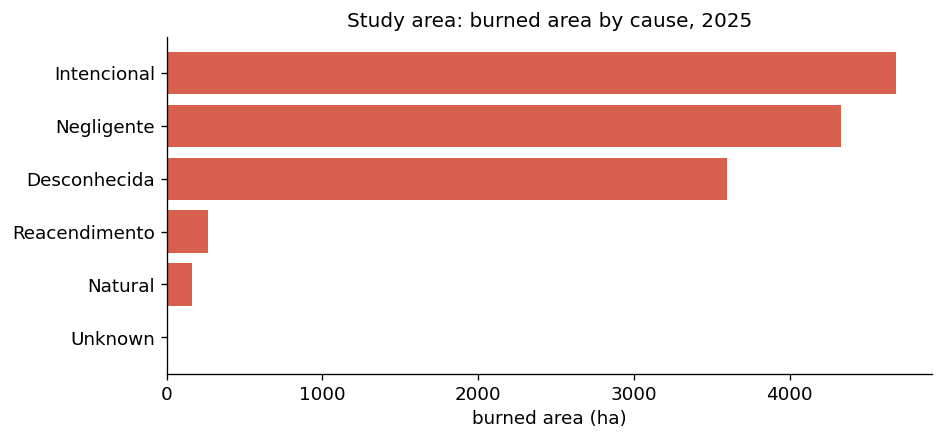

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.8))
cau = cause.sort_values("ha"); ax.barh(cau.index, cau["ha"], color=ACCENT)
ax.set_xlabel("burned area (ha)"); ax.set_title("Study area: burned area by cause, 2025")
plt.tight_layout(); plt.show()

*Observation.* In the study area human causes lead: intentional and negligent
fires together account for about two-thirds of the burned area, while natural
ignition is negligible (around 1 percent).

#### 3.4.2 Burned area by land cover

**Objective.** Sum the land-cover split. **Assumption.** `AreaHaPov` (forest),
`AreaHaMato` (shrubland), `AreaHaAgri` (agriculture).

In [16]:
lc = pd.Series({"forest (Pov)": fa["AreaHaPov"].sum(), "shrubland (Mato)": fa["AreaHaMato"].sum(),
                "agriculture (Agri)": fa["AreaHaAgri"].sum()})
pd.DataFrame({"ha": lc.round(0), "%": (100*lc/lc.sum()).round(1)})

,ha,%
forest (Pov),4057.0,32.2
shrubland (Mato),7349.0,58.4
agriculture (Agri),1184.0,9.4


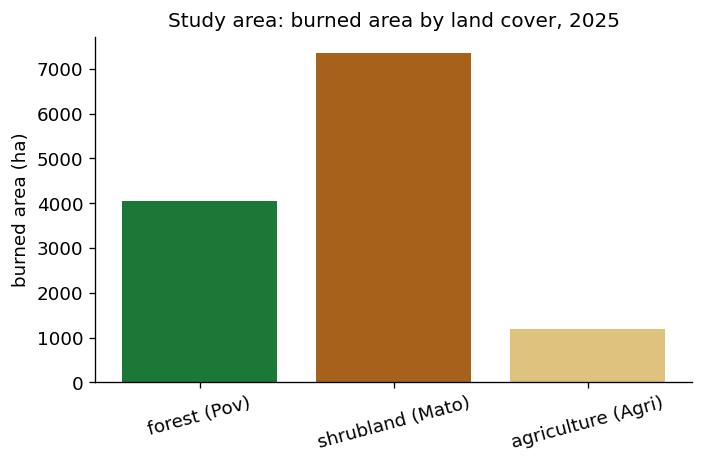

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(lc.index, lc.values, color=["#1b7837", "#a6611a", "#dfc27d"])
ax.set_ylabel("burned area (ha)"); ax.set_title("Study area: burned area by land cover, 2025")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

*Observation.* The vegetation split shows what burns in the study area;
shrubland and forest typically carry most of it, with agriculture a smaller share,
relevant because agricultural change is a known source of false alarms.

## 4. Summary

Nationally, 2025 was an extreme year (about 272,000 ha across 2,084 fires, with
August alone driving roughly 80 percent of the area). The study area, tile T29TPG in
Trás-os-Montes, holds a small share of the national fire count but the same fire
regime in miniature: many small fires but a few large August events that dominate
the burned area, with shrubland and forest carrying most of the damage. For the
burned-area mapping task this means the burned class is small, clustered and heavy
tailed, which is why the evaluation centres on the large events, why a minimum
fire-size filter is cheap in real area, and why the before/after scene pair must
bracket the short late-summer window.